
Model: Naive Bayes
              precision    recall  f1-score   support

    negative       0.33      0.17      0.22         6
     neutral       1.00      0.33      0.50         6
    positive       0.40      0.75      0.52         8

    accuracy                           0.45        20
   macro avg       0.58      0.42      0.41        20
weighted avg       0.56      0.45      0.43        20



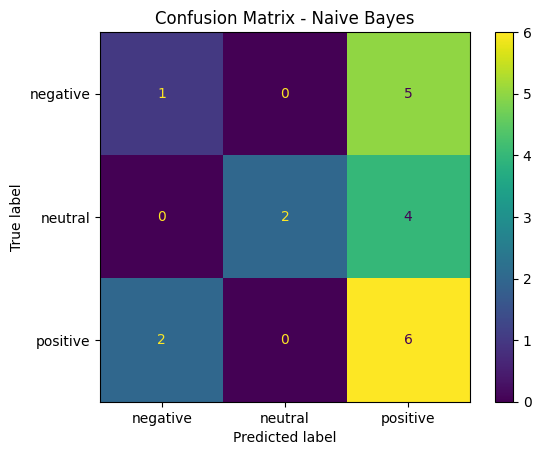


Model: SVM
              precision    recall  f1-score   support

    negative       0.45      0.83      0.59         6
     neutral       0.67      0.33      0.44         6
    positive       0.83      0.62      0.71         8

    accuracy                           0.60        20
   macro avg       0.65      0.60      0.58        20
weighted avg       0.67      0.60      0.60        20



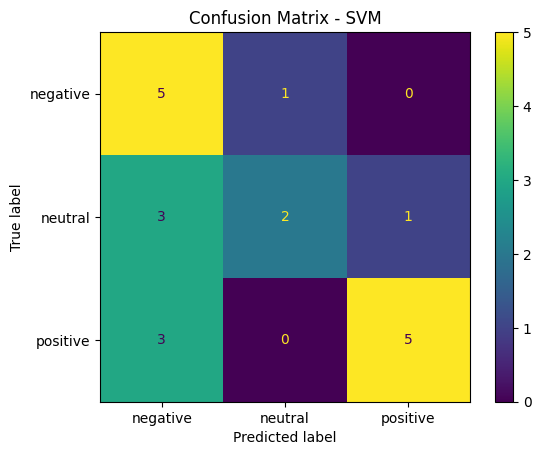


Model: Logistic Regression
              precision    recall  f1-score   support

    negative       0.33      0.17      0.22         6
     neutral       0.67      0.33      0.44         6
    positive       0.43      0.75      0.55         8

    accuracy                           0.45        20
   macro avg       0.48      0.42      0.40        20
weighted avg       0.47      0.45      0.42        20



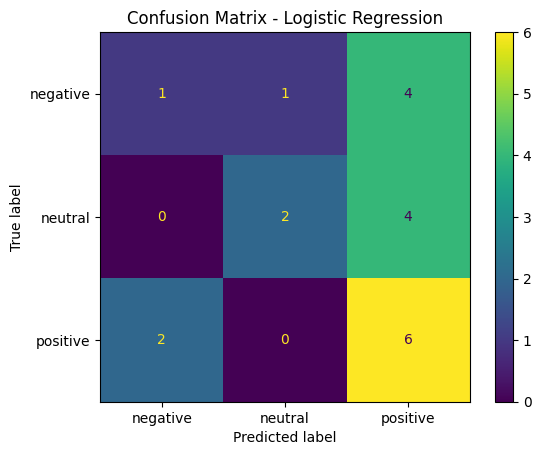

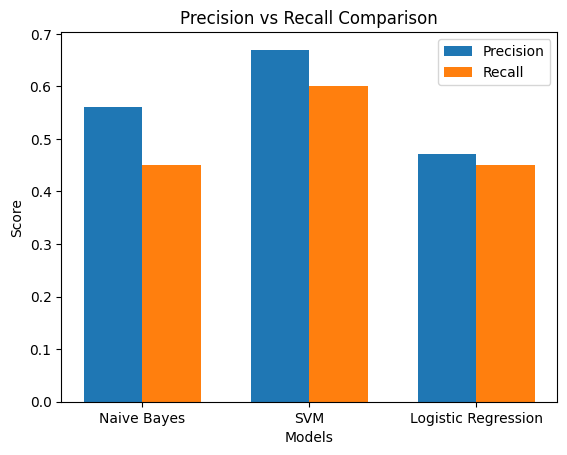

In [1]:
"""DAV.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1HGn3t4J7LLg1y4MbH8sClQjPlSlddKaD
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv("/content/avengers_tweets.csv")
df.head()

X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = []

for name, model in models.items():
    print("\n==============================")
    print(f"Model: {name}")
    print("==============================")

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print(classification_report(y_test, y_pred))

    results.append((name, precision, recall))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

model_names = [r[0] for r in results]
precisions = [r[1] for r in results]
recalls = [r[2] for r in results]

x = np.arange(len(model_names))
width = 0.35

plt.figure()

plt.bar(x - width/2, precisions, width)
plt.bar(x + width/2, recalls, width)

plt.xticks(x, model_names)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Precision vs Recall Comparison")

plt.legend(["Precision", "Recall"])

plt.show()